<a href="https://colab.research.google.com/github/rmarharyta/machinelearning/blob/main/%D0%A0%D1%83%D0%B1%D0%BB%D0%B5%D0%BD%D0%BA%D0%BE_%D0%9B%D0%A02_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Авторка роботи: Рубленко Маргарита Віталіївна ФІТ 4-10**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset
['titanic.csv']


In [ ]:
df = pd.read_csv(path + "/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


1. Вивести перших 5 рядків.


In [ ]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


2. Визначити розмір датасета

In [ ]:
df.shape

(891, 12)

3. Визначити тип даних

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


4. Визначити наявність пропущених значень. При наявності, замінити
пропущені значення на середнє значення.

In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
numeric_columns = df.select_dtypes(include=['number']).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].mean())

categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Complete")

Complete


5. Ще раз перевірити наявність пропущених значень.

In [ ]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


6. Перевірити наявність дублікатів. При наявності видалити дублікати.


In [ ]:
print(df.duplicated().sum())

0


7. Вивести описову статистику датасету describe()


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


8. Видалити стовпчик Cabin

In [ ]:
df = df.drop(columns=['Cabin'])

print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


9. Сформувати датасет з обраними стовпцями:
['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]


In [ ]:
df_selected = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df_selected.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


10. Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні
значення даного стовпчика).

In [ ]:
print(df_selected['Sex'].unique())

['male' 'female']


In [ ]:
df_selected['Sex'] = df_selected['Sex'].map({
    'male': 0,
    'female': 1
})

print(df_selected.head())

   Survived  Pclass  Sex   Age     Fare
0         0       3    0  22.0   7.2500
1         1       1    1  38.0  71.2833
2         1       3    1  26.0   7.9250
3         1       1    1  35.0  53.1000
4         0       3    0  35.0   8.0500


/tmp/ipykernel_1049/2521824307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Sex'] = df_selected['Sex'].map({


11. Ще раз перевірити кількість пропущених даних (впевнитись, що їх
немає)

In [ ]:
print(df_selected.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64


12. Вивести 5 перших рядків датасету.

In [ ]:
df_selected.head(5)

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


13. Вивести 5 останніх рядків датасету

In [ ]:
df_selected.tail(5)

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.000000,13.00
887,1,1,1,19.000000,30.00
888,0,3,1,29.699118,23.45
889,1,1,0,26.000000,30.00
890,0,3,0,32.000000,7.75


14. Аналіз виживання залежно від статі: Обчисліть відсоток виживання
для кожної статі. Чи була різниця у виживанні між чоловіками та
жінками?

In [ ]:
male = survival_by_sex[0]
female = survival_by_sex[1]

print(f"Чоловіки: {male:.2f}%")
print(f"Жінки: {female:.2f}%")

if female > male:
    print("Висновок: рівень виживання жінок був вищим за рівень виживання чоловіків.")
else:
    print("Висновок: рівень виживання чоловіків був вищим за рівень виживання жінок.")

Чоловіки: 18.89%
Жінки: 74.20%
Висновок: рівень виживання жінок був вищим за рівень виживання чоловіків.


15. Обчисліть відсоток виживання для кожного класу (Pclass). Який
клас мав найвищий рівень виживання (дати відповідь)?

In [ ]:
survival_by_class = df_selected.groupby('Pclass')['Survived'].mean() * 100

print("Відсоток виживання для кожного класу:")
print(survival_by_class)

Відсоток виживання для кожного класу:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


16. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи
впливає вік на виживання (дати відповідь)?

In [ ]:
average_age = df_selected.groupby('Survived')['Age'].mean()

print("Середній вік тих, хто не вижив:",
      round(average_age[0], 2))

print("Середній вік тих, хто вижив:",
      round(average_age[1], 2))

Середній вік тих, хто не вижив: 30.42
Середній вік тих, хто вижив: 28.55


In [ ]:
if average_age[1] < average_age[0]:
    print("\nВисновок: ті, хто вижив, у середньому були молодшими.")
else:
    print("\nВисновок: ті, хто вижив, у середньому були старшими.")


Висновок: ті, хто вижив, у середньому були молодшими.


17. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і
обчисліть рівень виживання для кожної групи. Як тариф впливав на
шанси виживання (дати відповідь)?

In [ ]:
df_selected['FareGroup'] = pd.qcut(
    df_selected['Fare'],
    q=4,
    labels=['Низький', 'Середній', 'Високий', 'Дуже високий']
)

survival_by_fare = df_selected.groupby(
    'FareGroup',
    observed=False
)['Survived'].mean() * 100

print("Рівень виживання за групами тарифів:")
print(survival_by_fare)

Рівень виживання за групами тарифів:
FareGroup
Низький         19.730942
Середній        30.357143
Високий         45.495495
Дуже високий    58.108108
Name: Survived, dtype: float64


/tmp/ipykernel_1049/1199267178.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['FareGroup'] = pd.qcut(


In [ ]:
lowest = survival_by_fare.iloc[0]
highest = survival_by_fare.iloc[-1]

print(f"\nНизький тариф: {lowest:.2f}%")
print(f"Дуже високий тариф: {highest:.2f}%")

if highest > lowest:
    print("Висновок: пасажири з вищими тарифами мали вищий рівень виживання.")
else:
    print("Висновок: пасажири з вищими тарифами не мали вищого рівня виживання.")


Низький тариф: 19.73%
Дуже високий тариф: 58.11%
Висновок: пасажири з вищими тарифами мали вищий рівень виживання.


18. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного
класу (Pclass). Чи існує значна різниця у тарифах між класами (дати
відповідь)?

In [ ]:
average_fare = df_selected.groupby('Pclass')['Fare'].mean()

print("Середній тариф для кожного класу:")
print(average_fare)

Середній тариф для кожного класу:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


19. Обчисліть середній вік пасажирів для кожного класу (Pclass). Як вік
пасажирів розподіляється за класами (дати відповідь)?


In [ ]:
average_age_by_class = df_selected.groupby('Pclass')['Age'].mean()

print("Середній вік пасажирів за класами:")

for pclass, age in average_age_by_class.items():
    print(f"{pclass}-й клас: {age:.2f} років")

Середній вік пасажирів за класами:
1-й клас: 37.05 років
2-й клас: 29.87 років
3-й клас: 26.40 років


20. Побудуйте гістограму розподілу віку для тих, хто вижив, і тих, хто
не вижив. Чи є видимі відмінності у вікових групах (дати
відповідь)?

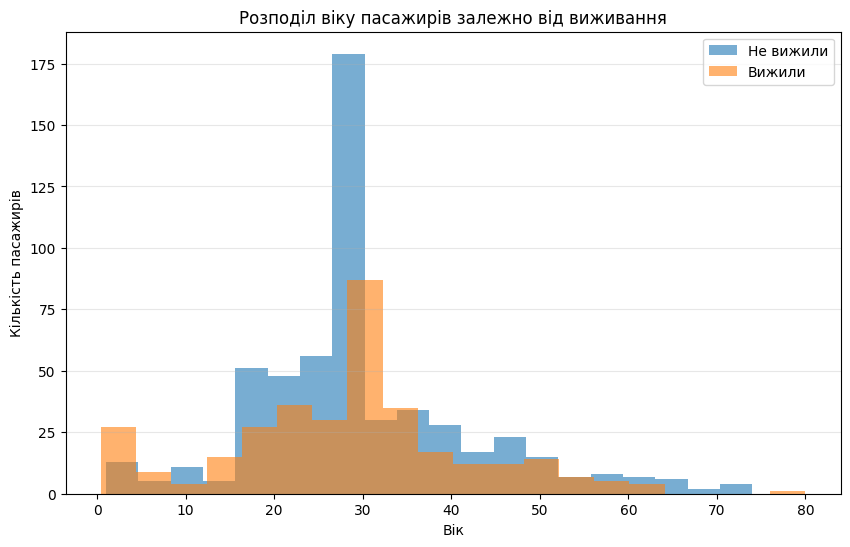

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    df_selected[df_selected['Survived'] == 0]['Age'],
    bins=20,
    alpha=0.6,
    label='Не вижили'
)

plt.hist(
    df_selected[df_selected['Survived'] == 1]['Age'],
    bins=20,
    alpha=0.6,
    label='Вижили'
)

plt.xlabel('Вік')
plt.ylabel('Кількість пасажирів')
plt.title('Розподіл віку пасажирів залежно від виживання')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

21. Обчисліть відсоток виживання для кожної комбінації статі та класу
(наприклад, жінки в 1-му класі, чоловіки в 3-му класі). Яка група
мала найвищий рівень виживання (дати відповідь)?

In [ ]:
survival_by_sex_class = (
    df_selected
    .groupby(['Sex', 'Pclass'])['Survived']
    .mean() * 100
)

print("Відсоток виживання за статтю та класом:")

for (sex, pclass), rate in survival_by_sex_class.items():

    if sex == 0:
        sex_name = "Чоловіки"
    else:
        sex_name = "Жінки"

    print(f"{sex_name}, {pclass}-й клас: {rate:.2f}%")

Відсоток виживання за статтю та класом:
Чоловіки, 1-й клас: 36.89%
Чоловіки, 2-й клас: 15.74%
Чоловіки, 3-й клас: 13.54%
Жінки, 1-й клас: 96.81%
Жінки, 2-й клас: 92.11%
Жінки, 3-й клас: 50.00%


22. Обчисліть кореляцію між усіма числовими змінними (Survived,
Pclass, Age, Fare). Які змінні найбільш сильно корелюють з
виживанням (дати відповідь)?

In [ ]:
numeric_data = df_selected[
    ['Survived', 'Pclass', 'Age', 'Fare']
]

correlation = numeric_data.corr()

print(correlation)

          Survived    Pclass       Age      Fare
Survived  1.000000 -0.338481 -0.069809  0.257307
Pclass   -0.338481  1.000000 -0.331339 -0.549500
Age      -0.069809 -0.331339  1.000000  0.091566
Fare      0.257307 -0.549500  0.091566  1.000000


In [ ]:
survival_correlation = correlation['Survived'].drop('Survived')

print("Кореляція з Survived:")
print(survival_correlation)

strongest = survival_correlation.abs().idxmax()

print(
    f"\nНайсильніше з виживанням корелює: {strongest}"
)
print(
    f"Коефіцієнт кореляції: "
    f"{survival_correlation[strongest]:.3f}"
)

Кореляція з Survived:
Pclass   -0.338481
Age      -0.069809
Fare      0.257307
Name: Survived, dtype: float64

Найсильніше з виживанням корелює: Pclass
Коефіцієнт кореляції: -0.338
